Iris Dataset Classifier

Here we build and evaluate a neural network for the Iris dataset. We compare two different sizes, check stats, and find the accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

Data loading and stats

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


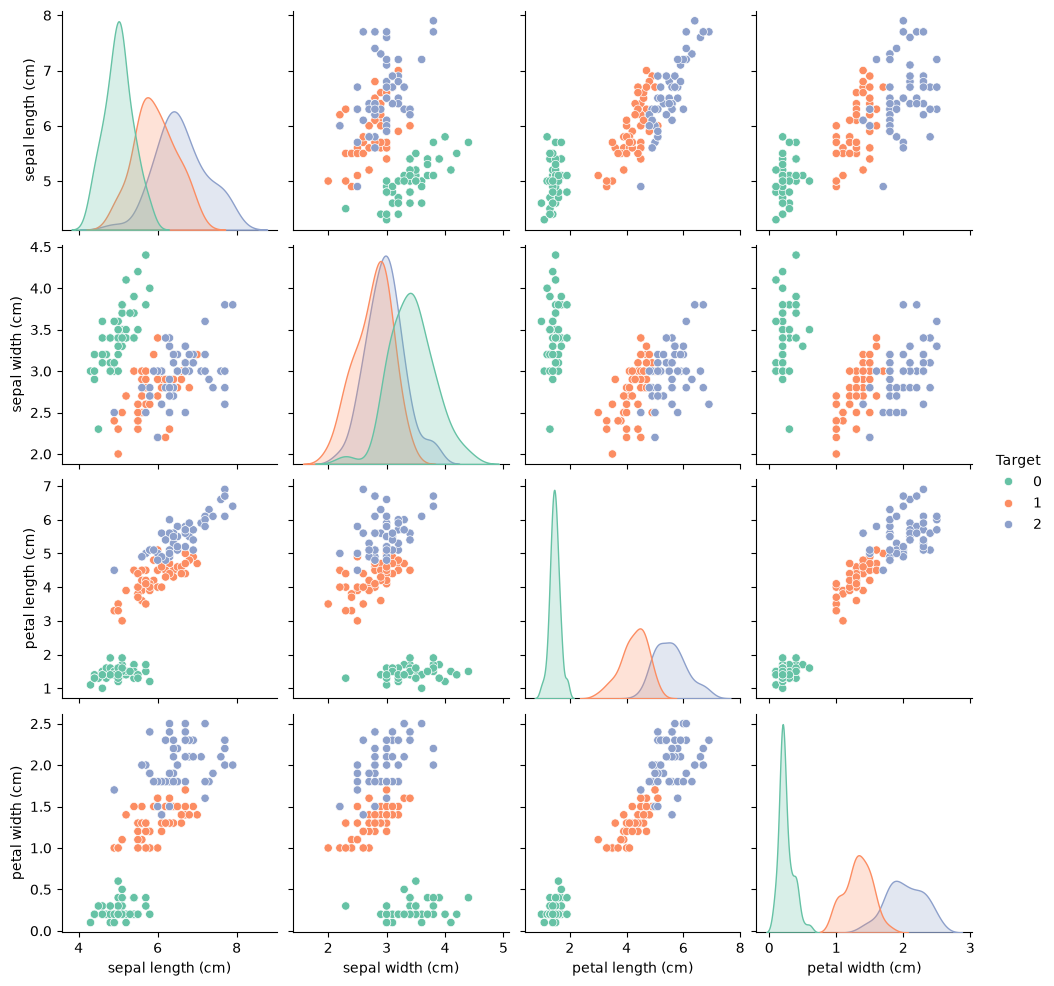

In [2]:
# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Target'] = iris.target

# Statistical inferences (Summary Statistics)
display(df.describe())

# Exploratory Data Analysis (EDA) - Pairplot
sns.pairplot(df, hue='Target', palette='Set2')
plt.show()

Preprocessing and cross-validation

We scale the features and compare two different neural network sizes using cross-validation.

In [3]:
X = df.drop('Target', axis=1)
y = df['Target']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define two different MLP architectures
arch1 = (10, 10)       # Architecture 1: 2 hidden layers with 10 neurons each
arch2 = (50, 50, 50)   # Architecture 2: 3 hidden layers with 50 neurons each

# Initialize Multi-Layer Perceptron Classifiers
mlp1 = MLPClassifier(hidden_layer_sizes=arch1, max_iter=1500, random_state=42)
mlp2 = MLPClassifier(hidden_layer_sizes=arch2, max_iter=1500, random_state=42)

# 5-Fold Cross Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores1 = cross_val_score(mlp1, X_scaled, y, cv=cv, scoring='accuracy')
scores2 = cross_val_score(mlp2, X_scaled, y, cv=cv, scoring='accuracy')

print(f"Architecture 1 {arch1} Mean CV Accuracy: {scores1.mean():.4f} (+/- {scores1.std() * 2:.4f})")
print(f"Architecture 2 {arch2} Mean CV Accuracy: {scores2.mean():.4f} (+/- {scores2.std() * 2:.4f})")

Architecture 1 (10, 10) Mean CV Accuracy: 0.9600 (+/- 0.0267)
Architecture 2 (50, 50, 50) Mean CV Accuracy: 0.9467 (+/- 0.0327)


Final evaluation

We train the chosen model and check its accuracy on the test set.

Test Accuracy: 0.9778


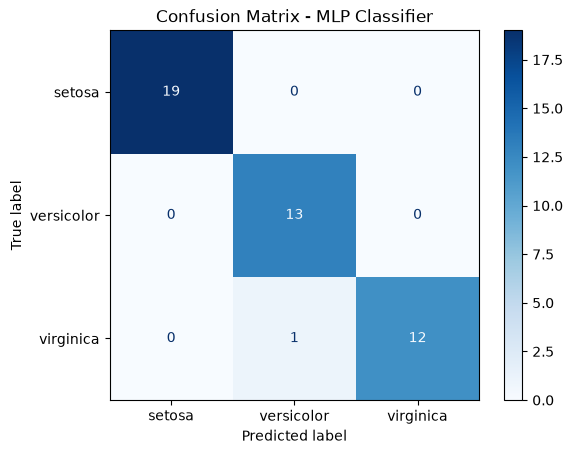

In [4]:
# Train-test split for final evaluation
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train the chosen architecture
best_mlp = MLPClassifier(hidden_layer_sizes=arch2, max_iter=1500, random_state=42)
best_mlp.fit(X_train, y_train)

# Predictions
y_pred = best_mlp.predict(X_test)

# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - MLP Classifier")
plt.show()